In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
df = pd.read_csv(r"C:\Users\start\Desktop\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2833,5993-JSUWV,Female,0,No,No,66,Yes,No,DSL,Yes,...,Yes,No,No,No,Two year,Yes,Bank transfer (automatic),61.15,4017.45,No
1585,4522-XRWWI,Male,0,Yes,No,42,Yes,Yes,DSL,Yes,...,No,Yes,Yes,Yes,One year,No,Credit card (automatic),80.45,3375.9,No
305,1248-DYXUB,Male,0,Yes,Yes,52,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,24.80,1229.1,No
456,5149-CUZUJ,Male,0,Yes,Yes,28,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,No,One year,No,Bank transfer (automatic),92.90,2768.35,No
52,6575-SUVOI,Female,1,Yes,No,25,Yes,Yes,DSL,Yes,...,No,Yes,Yes,No,Month-to-month,Yes,Credit card (automatic),69.50,1752.65,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [12]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
for col in df.drop(columns=["customerID"]).columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"{'='*60}")

    display(pd.DataFrame({
        "Count": df[col].value_counts(dropna=False),
        "Percentage (%)": (df[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    }))


Column: gender


,Count,Percentage (%)
gender,,
Male,3555,50.48
Female,3488,49.52



Column: SeniorCitizen


,Count,Percentage (%)
SeniorCitizen,,
0,5901,83.79
1,1142,16.21



Column: Partner


...

,Count,Percentage (%)
MonthlyCharges,,
20.05,61,0.87
19.85,45,0.64
19.95,44,0.62
19.90,44,0.62
20.00,43,0.61
...,...,...
23.65,1,0.01
114.70,1,0.01
43.65,1,0.01



Column: TotalCharges


,Count,Percentage (%)
TotalCharges,,
,11,0.16
20.2,11,0.16
19.75,9,0.13
20.05,8,0.11
19.9,8,0.11
...,...,...
6849.4,1,0.01
692.35,1,0.01
130.15,1,0.01



Column: Churn


,Count,Percentage (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


- customerID: A unique identifier assigned to each customer. It is used only for identification and does not contribute to churn prediction.
- gender: Represents the customer's gender (Male or Female).
- SeniorCitizen: Indicates whether the customer is a senior citizen (1 = Yes, 0 = No).
- Partner:Shows whether the customer has a partner or spouse.
- Dependents: Indicates whether the customer has dependents.
- tenure: Represents the number of months the customer has stayed with the company.
- PhoneService: Indicates whether the customer subscribes to phone service.
- MultipleLines: Shows whether the customer has multiple phone lines.
- InternetService: Represents the type of internet service the customer uses (DSL, Fiber optic, or No service).
- OnlineSecurity: Indicates whether the customer has subscribed to the online security service.
- OnlineBackup: Shows whether the customer has subscribed to the online backup service.
- DeviceProtection: Indicates whether the customer has device protection.
- TechSupport: Shows whether the customer has access to technical support.
- StreamingTV: Indicates whether the customer subscribes to TV streaming services.
- StreamingMovies: Shows whether the customer subscribes to movie streaming services.
- Contract: Represents the customer's contract type (Month-to-month, One year, or Two year).
- PaperlessBilling: Indicates whether the customer uses paperless billing.
- PaymentMethod: Represents the payment method used by the customer.
- MonthlyCharges: Shows the amount charged to the customer each month.
- TotalCharges:Represents the total amount charged to the customer over their entire subscription period.
- Churn: The target variable indicating whether the customer left the company (Yes) or remained (No).

In [15]:
df.drop(columns="customerID", inplace=True)

Dropping customerID
The `customerID` column was removed because it is a unique identifier and does not provide useful information for predicting customer churn.

In [17]:
df["TotalCharges"].dtype

dtype('O')

In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [19]:
df["TotalCharges"].dtype

dtype('float64')

In [20]:
df["TotalCharges"].isnull().sum()

11

In [21]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

C:\Users\start\AppData\Local\Temp\ipykernel_28932\1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


Converting TotalCharges
The `TotalCharges` column was converted from object to numeric format. Any invalid values generated during conversion were replaced with the median value.

In [23]:
df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

In [24]:
df = pd.get_dummies(df, drop_first=True)

Encoding Categorical Features
Categorical variables were converted into numerical representations using one-hot encoding to make them suitable for machine learning algorithms.

In [26]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
df.shape[1]

31

In [30]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


# ModelsTraining

## Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [34]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [35]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

In [36]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8069552874378992
Precision: 0.6583850931677019
Recall   : 0.5668449197860963
F1-Score : 0.6091954022988506
ROC-AUC  : 0.8415846443979436


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



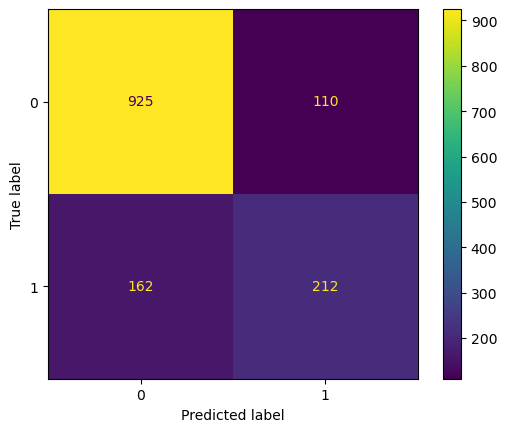

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.show()

## Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1:", grid_rf.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1: 0.5724855828145436


In [42]:
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

In [43]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8034066713981547
Precision: 0.6611295681063123
Recall   : 0.5320855614973262
F1 Score : 0.5896296296296296
ROC-AUC  : 0.8408070474566637


In [44]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



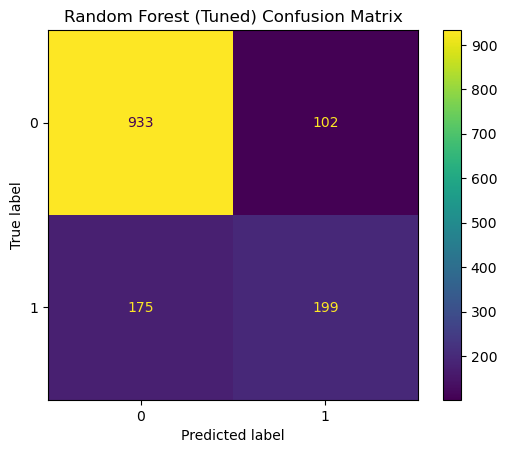

In [45]:
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("Random Forest (Tuned) Confusion Matrix")
plt.show()

## XGBoost

In [47]:
from xgboost import XGBClassifier

In [48]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV F1:", grid_xgb.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1: 0.588646685896854


In [49]:
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

In [50]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.7955997161107168
Precision: 0.6423841059602649
Recall   : 0.5187165775401069
F1 Score : 0.5739644970414202
ROC-AUC  : 0.8447957839262186


In [51]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



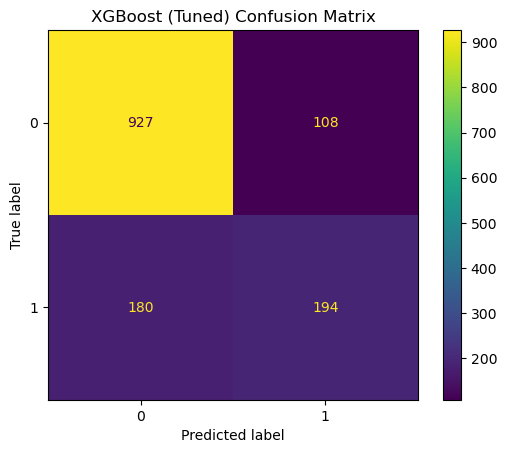

In [52]:
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test)
plt.title("XGBoost (Tuned) Confusion Matrix")
plt.show()

In [53]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest (Tuned)", "XGBoost (Tuned)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841585
1,Random Forest (Tuned),0.803407,0.661130,0.532086,0.589630,0.840807
2,XGBoost (Tuned),0.795600,0.642384,0.518717,0.573964,0.844796


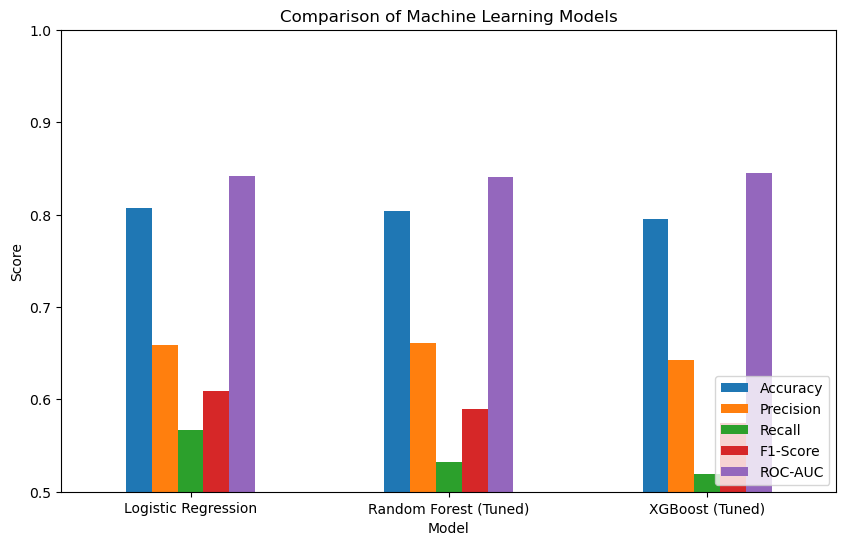

In [54]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0.5,1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [55]:
import joblib

joblib.dump(lr, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [56]:
feature_names = X.columns.tolist()

joblib.dump(feature_names, "features.pkl")

['features.pkl']

In [60]:
from sklearn.metrics import accuracy_score

# Logistic Regression
lr_train_acc = accuracy_score(y_train, lr.predict(X_train))
lr_test_acc = accuracy_score(y_test, lr.predict(X_test))

print("Logistic Regression")
print("Train Accuracy:", lr_train_acc)
print("Test Accuracy :", lr_test_acc)

Logistic Regression
Train Accuracy: 0.8059992900248492
Test Accuracy : 0.8069552874378992


In [62]:
# Random Forest
rf_train_acc = accuracy_score(y_train, best_rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, best_rf.predict(X_test))

print("Random Forest")
print("Train Accuracy:", rf_train_acc)
print("Test Accuracy :", rf_test_acc)

Random Forest
Train Accuracy: 0.8549875754348598
Test Accuracy : 0.8034066713981547


In [64]:
# XGBoost
xgb_train_acc = accuracy_score(y_train, best_xgb.predict(X_train))
xgb_test_acc = accuracy_score(y_test, best_xgb.predict(X_test))

print("XGBoost")
print("Train Accuracy:", xgb_train_acc)
print("Test Accuracy :", xgb_test_acc)

XGBoost
Train Accuracy: 0.821618743343983
Test Accuracy : 0.7955997161107168
